<a href="https://colab.research.google.com/github/raisharad/GenerativeAIandAgenticAI/blob/main/PEFT_Sequential_Adapters_C2_Demo1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##<font color="blue"><b>-----Parameter-Efficient Fine-Tuning with Sequential Adapters-----</b></font>

### <font color="purple">**Problem Statement: Sequential Adapters**</font>

When we fine-tune a pretrained model like BERT for a new task, we usually update all of its parameters. This takes a lot of compute, and we need to save a full copy of the model for every task. In this demo, we use **Sequential Adapters** ([Houlsby et al., 2019](https://proceedings.mlr.press/v97/houlsby19a/houlsby19a.pdf)) to adapt BERT to the **SST-2 sentiment task**. We keep BERT **frozen** and train only small **adapter** layers added inside the model, along with the LayerNorm layers and the classifier. The goal is to **train far fewer parameters while getting accuracy close to full fine-tuning**.

### <font color="purple">**Learning Objectives:**</font>

- Understand the difference between **Full Fine-Tuning** and **Parameter-Efficient Fine-Tuning (PEFT) - Adapter Tuning**.
- Understand the architecture and working of **Sequential Adapters**.
- Learn how adapters reduce the number of **trainable parameters** while adapting a pretrained model.
- Compare Full Fine-Tuning and Sequential Adapters based on **task performance and parameter efficiency**.
- Analyze training and validation curves to understand the **learning behavior** of both approaches.

In [ ]:
import gc
import math
import random
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from collections import OrderedDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer, PrinterCallback

In [ ]:
from transformers.utils import logging
logging.set_verbosity_error()

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [ ]:
MODEL_NAME  = "bert-base-uncased"
TRAIN_SIZE  = 1000     # None = full SST-2 train (67,349)
EPOCHS      = 3
BATCH_SIZE  = 64
MAX_LEN     = 128
ADAPTER_M   = 64        # bottleneck size
WARMUP_FRAC = 0.1
SEED        = 42

set_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

raw = load_dataset("nyu-mll/glue", "sst2")
print(raw)
display(raw["train"].to_pandas().head())

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

README.md:   0%|          | 0.00/35.3k [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})


,sentence,label,idx
0,hide new secretions from the parental units,0,0
1,"contains no wit , only labored gags",0,1
2,that loves its characters and communicates som...,1,2
3,remains utterly satisfied to remain the same t...,0,3
4,on the worst revenge-of-the-nerds clichés the ...,0,4


In [ ]:
# ===========================================================================
# Tokenize, take the training subset, pad per batch
# ===========================================================================
def tokenize(batch):
    return tokenizer(batch["sentence"], truncation=True, max_length=MAX_LEN)

tokenized = raw.map(tokenize, batched=True, remove_columns=["sentence", "idx"])
tokenized = tokenized.rename_column("label", "labels")

train_ds = tokenized["train"].shuffle(seed=SEED)
if TRAIN_SIZE is not None:
    train_ds = train_ds.select(range(TRAIN_SIZE))
eval_ds  = tokenized["validation"]

collator = DataCollatorWithPadding(tokenizer)

print(f"Train: {len(train_ds):,} | Eval (validation): {len(eval_ds):,}")

Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/1821 [00:00<?, ? examples/s]

Train: 1,000 | Eval (validation): 872


### Adapter Architecture
<img src="https://raw.githubusercontent.com/Rekha215/Demo-Images/refs/heads/main/adapter_seq.png" width="700">

In [ ]:
# ===========================================================================
# Bottleneck adapter:  h -> h + W_up(GELU(W_down h))
# ===========================================================================
def build_base():
    set_seed(SEED)
    return AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

class Adapter(nn.Module):
    def __init__(self, d=768, m=ADAPTER_M,):
        super().__init__()
        self.down = nn.Linear(d, m)
        self.act  = nn.GELU()
        self.up   = nn.Linear(m, d)

    def forward(self, h):
        return h + self.up(self.act(self.down(h)))

In [ ]:
# ===========================================================================
# Insert adapters after each block's output projections
#   attention:  LayerNorm( Adapter(attention.output.dense(attn)) + x )
#   FFN:        LayerNorm( Adapter(output.dense(intermediate))  + h )
# ===========================================================================

# creates a small adapter block by combining an existing projection layer with an Adapter.
def with_adapter(proj, d, m):
    return nn.Sequential(OrderedDict([("proj", proj), ("adapter", Adapter(d, m))]))

def insert_adapters(model, m=ADAPTER_M):
    d = model.config.hidden_size
    for layer in model.bert.encoder.layer:
        layer.attention.output.dense = with_adapter(layer.attention.output.dense, d, m)
        layer.output.dense           = with_adapter(layer.output.dense, d, m)
    return model

base_model = build_base()
demo = insert_adapters(build_base())

print(base_model.bert.encoder.layer[0])
print("***********************************")
print("After adding adapters------")
print("***********************************")
print(demo.bert.encoder.layer[0])

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertLayer(
  (attention): BertAttention(
    (self): BertSelfAttention(
      (query): Linear(in_features=768, out_features=768, bias=True)
      (key): Linear(in_features=768, out_features=768, bias=True)
      (value): Linear(in_features=768, out_features=768, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (output): BertSelfOutput(
      (dense): Linear(in_features=768, out_features=768, bias=True)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (intermediate): BertIntermediate(
    (dense): Linear(in_features=768, out_features=3072, bias=True)
    (intermediate_act_fn): GELUActivation()
  )
  (output): BertOutput(
    (dense): Linear(in_features=3072, out_features=768, bias=True)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
)
***********************************
After adding adapters------
*****************

In [ ]:
# ===========================================================================
# Helpers
# ===========================================================================
def is_adapter(n):
  return ".adapter." in n
def is_layernorm(n):
  return "LayerNorm" in n
def is_head(n):
  return n.startswith("classifier")

def set_trainable(model, rule):
    for n, p in model.named_parameters():
        p.requires_grad = rule(n)

def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def free_gpu():
    gc.collect()
    if device == "cuda":
        torch.cuda.empty_cache()

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    return {"accuracy": (np.argmax(logits, -1) == labels).mean()}

def training_log(history):
    tr = {round(r["epoch"]): r for r in history if "eval_train_loss" in r}
    va = {round(r["epoch"]): r for r in history if "eval_val_loss" in r}
    return pd.DataFrame([{
        "Epoch":          e,
        "Train Loss":     tr[e]["eval_train_loss"],
        "Train Accuracy": tr[e]["eval_train_accuracy"],
        "Val Loss":       va[e]["eval_val_loss"],
        "Val Accuracy":   va[e]["eval_val_accuracy"],
    } for e in sorted(va)])

In [ ]:
# ===========================================================================
# Reusable training: evaluate train + val at the end of every epoch
# ===========================================================================
trained = {}

def run_training(name, model, lr):
    free_gpu()
    model.to(device)
    total, trainable = count_params(model)
    print(f"{name}: trainable {trainable:,} / {total:,} ({100 * trainable / total:.2f}%)")

    total_steps  = math.ceil(len(train_ds) / BATCH_SIZE) * EPOCHS
    warmup_steps = int(WARMUP_FRAC * total_steps)

    args = TrainingArguments(
        output_dir=f"./out/{name.replace(' ', '_')}",
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        learning_rate=lr,
        warmup_steps=warmup_steps,
        lr_scheduler_type="linear",
        eval_strategy="epoch",
        logging_strategy="epoch",
        save_strategy="no",
        fp16=(device == "cuda"),
        seed=SEED,
        report_to=[],
    )
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset={"train": train_ds, "val": eval_ds},
        data_collator=collator,
        compute_metrics=compute_metrics,
    )

    # Removes Hugging Face's PrinterCallback, so the Trainer stops printing its default training progress/log messages in the console.
    trainer.remove_callback(PrinterCallback)

    trainer.train()
    history = trainer.state.log_history
    display(training_log(history).round(4))

    model.to("cpu")
    del trainer
    free_gpu()
    trained[name] = {"model": model, "history": history}

In [ ]:
def evaluate_model(model):
    model.to(device).eval()
    args = TrainingArguments(
        output_dir="./out/eval",
        per_device_eval_batch_size=BATCH_SIZE,
        fp16=(device == "cuda"),
        report_to=[],
    )
    trainer = Trainer(model=model, args=args, eval_dataset=eval_ds, data_collator=collator, compute_metrics=compute_metrics)
    metrics = trainer.evaluate()
    model.to("cpu")
    del trainer
    free_gpu()
    return metrics

In [ ]:
# --- Full Fine-Tuning ---
model = build_base()
set_trainable(model, lambda n: True)
run_training("Full FT", model, lr=3e-5)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Full FT: trainable 109,483,778 / 109,483,778 (100.00%)


,Epoch,Train Loss,Train Accuracy,Val Loss,Val Accuracy
0,1,0.5695,0.677,0.6042,0.6468
1,2,0.2966,0.918,0.3788,0.8509
2,3,0.2373,0.934,0.3557,0.8567


In [ ]:
# --- Sequential (Houlsby) Adapters ---
model = insert_adapters(build_base())
set_trainable(model, lambda n: is_adapter(n) or is_layernorm(n) or is_head(n))
run_training("Houlsby Adapter", model, lr=3e-4)
del model

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Houlsby Adapter: trainable 2,419,202 / 111,863,042 (2.16%)


,Epoch,Train Loss,Train Accuracy,Val Loss,Val Accuracy
0,1,0.6401,0.585,0.6707,0.5149
1,2,0.4709,0.802,0.5125,0.7683
2,3,0.3466,0.881,0.4080,0.8349


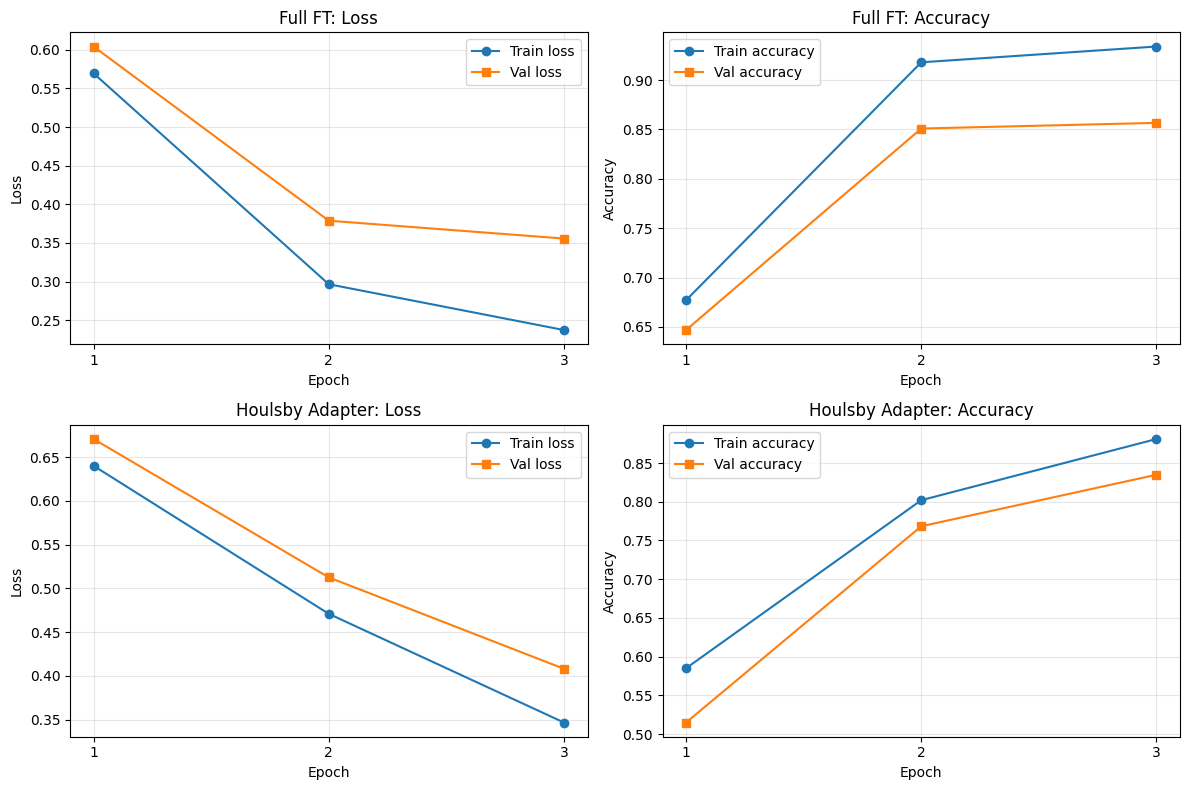

In [ ]:
# ===========================================================================
# Training curves: train vs val loss and accuracy per epoch
# ===========================================================================
def get_curves(history, split):
    recs = [r for r in history if f"eval_{split}_loss" in r]
    return ([round(r["epoch"]) for r in recs],
            [r[f"eval_{split}_loss"] for r in recs],
            [r[f"eval_{split}_accuracy"] for r in recs])

fig, axes = plt.subplots(len(trained), 2, figsize=(12, 4 * len(trained)), squeeze=False)

for row, (name, rec) in enumerate(trained.items()):
    tr_ep, tr_loss, tr_acc = get_curves(rec["history"], "train")
    va_ep, va_loss, va_acc = get_curves(rec["history"], "val")

    axes[row, 0].plot(tr_ep, tr_loss, marker="o", label="Train loss")
    axes[row, 0].plot(va_ep, va_loss, marker="s", label="Val loss")
    axes[row, 0].set_title(f"{name}: Loss")
    axes[row, 0].set_ylabel("Loss")

    axes[row, 1].plot(tr_ep, tr_acc, marker="o", label="Train accuracy")
    axes[row, 1].plot(va_ep, va_acc, marker="s", label="Val accuracy")
    axes[row, 1].set_title(f"{name}: Accuracy")
    axes[row, 1].set_ylabel("Accuracy")

    for ax in axes[row]:
        ax.set_xlabel("Epoch")
        ax.set_xticks(range(1, EPOCHS + 1))
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

{'eval_loss': '0.3557', 'eval_model_preparation_time': '0', 'eval_accuracy': '0.8567', 'eval_runtime': '0.3493', 'eval_samples_per_second': '2496', 'eval_steps_per_second': '40.08', 'epoch': 0}
{'eval_loss': '0.408', 'eval_model_preparation_time': '0', 'eval_accuracy': '0.8349', 'eval_runtime': '0.4012', 'eval_samples_per_second': '2174', 'eval_steps_per_second': '34.9', 'epoch': 0}


,config,accuracy,delta_acc_vs_full_FT,trainable_params,trainable_%
0,Full FT,0.8567,0.0000,109483778,100.0000
1,Houlsby Adapter,0.8349,-0.0218,2419202,2.1626


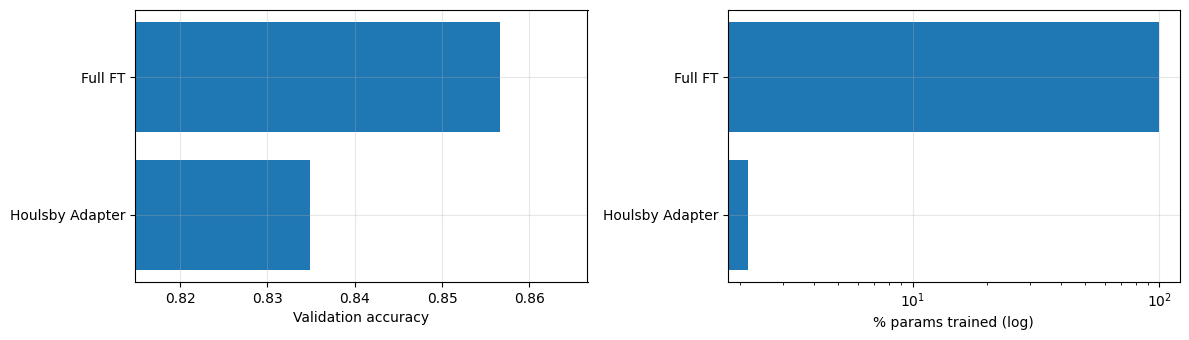

In [ ]:
# ===========================================================================
# Compare results
# ===========================================================================
rows = []
for name, rec in trained.items():
    acc = evaluate_model(rec["model"])["eval_accuracy"]
    total, trainable = count_params(rec["model"])
    rows.append({
        "config":           name,
        "accuracy":         acc,
        "trainable_params": trainable,
        "trainable_%":      100 * trainable / total,
    })
results = pd.DataFrame(rows)
results["delta_acc_vs_full_FT"] = results["accuracy"] - results.loc[results.config == "Full FT", "accuracy"].item()
display(results[["config", "accuracy", "delta_acc_vs_full_FT", "trainable_params", "trainable_%"]].round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

axes[0].barh(results.config, results.accuracy)
axes[0].set_xlim(results.accuracy.min() - 0.02, results.accuracy.max() + 0.01)
axes[0].set_xlabel("Validation accuracy")

axes[1].barh(results.config, results["trainable_%"])
axes[1].set_xscale("log")
axes[1].set_xlabel("% params trained (log)")

for ax in axes:
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### <font color="purple">**Summary**</font>

1. This experiment compares **Full Fine-Tuning** with **Sequential (Houlsby) Adapters** for adapting BERT-base to the SST-2 sentiment classification task.
2. The adapter approach inserts two bottleneck adapters into each BERT encoder block and trains the adapters, LayerNorms, and classification head while keeping the remaining BERT parameters frozen.
3. With 1,000 training examples, Full Fine-Tuning updates **109.48M parameters**, whereas the adapter configuration trains only **~2.2% of the parameters**.
4. Both approaches are evaluated on the **872-example SST-2 validation set**, using accuracy along with training and validation loss/accuracy curves.
5. The experiment demonstrates how parameter-efficient adaptation can substantially reduce the number of trainable parameters while maintaining competitive downstream-task performance.



### <font color="purple">**Future Directions**</font>

- **Increase training data:** Repeat the experiment using the full SST-2 training set to study how performance changes with more data.
- **Vary adapter size:** Compare different bottleneck dimensions such as **8, 64, and 256**.
- **Compare PEFT methods:** Extend the experiment to **LoRA, residual adapters, and layer freezing (like we did in earlier session)**.
- **Evaluate across tasks:** Test the approach on multiple GLUE tasks to examine whether the parameter-efficiency benefits generalize.
- **Study efficiency:** Compare **training time, GPU memory, and task-specific storage** in addition to accuracy.

In [ ]:
###------------END----------------###